# Witness Functions for Integral Probability Metrics

Dual norms compare measures through a restricted class of test functions.  This notebook plots three witnesses for the same pair of one-dimensional laws: a $\Wass_1$ Lipschitz witness, a Gaussian-kernel MMD witness, and a total-variation witness.  The point is to see the shape of the discriminator class, not to compare numerical values.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    remove_axes, box_axes, padded_limits, interp_color, draw_point_clouds,
)

setup_matplotlib()

NAME = "dualnorms-ipm-witnesses"
OUT = figure_dir(NAME)

The laws are smooth Gaussian mixtures.  Their densities are drawn faintly below the witness curves to keep the relation with the signed discrepancy visible.

In [2]:
def gaussian(x, m, s):
    return np.exp(-0.5*((x-m)/s)**2) / (np.sqrt(2*np.pi)*s)

grid = np.linspace(-3.2, 3.2, 700)
dx = grid[1] - grid[0]
rhoa = 0.50*gaussian(grid, -1.45, 0.32) + 0.50*gaussian(grid, 1.25, 0.36)
rhob = 0.65*gaussian(grid, -0.35, 0.45) + 0.35*gaussian(grid, 0.82, 0.28)
rhoa = rhoa / (rhoa.sum()*dx)
rhob = rhob / (rhob.sum()*dx)
Fa = np.cumsum(rhoa) * dx
Fb = np.cumsum(rhob) * dx
# Integration by parts gives the W1 maximizing derivative as sign(F_alpha-F_beta), up to convention.
w1_der = np.sign(Fa - Fb)
w1 = np.cumsum(w1_der) * dx
w1 -= np.mean(w1)
# Match the sign convention of the other witnesses: positive where alpha dominates beta.
w1 *= -1
w1 /= max(np.max(np.abs(w1)), 1e-12)
# RKHS witness: kernel mean difference for a Gaussian kernel, normalized for display.
sigma = 0.42
K = np.exp(-0.5*((grid[:, None] - grid[None, :])/sigma)**2)
mmd = K @ ((rhoa - rhob) * dx)
mmd -= np.mean(mmd)
mmd /= max(np.max(np.abs(mmd)), 1e-12)
tv = np.sign(rhoa - rhob)

Each witness is normalized only for plotting.  The normalization does not change the qualitative geometry of its dual ball.

In [3]:
def draw_witness(values, path, color=VIOLET, ylim=(-1.25, 1.25)):
    fig, ax = plt.subplots(figsize=(2.65, 1.95))
    base = ylim[0]
    scale = 0.24 * (ylim[1] - ylim[0])
    ax.fill_between(grid, base, base + scale*rhoa/rhoa.max(), color=RED, alpha=0.12, lw=0)
    ax.fill_between(grid, base, base + scale*rhob/rhob.max(), color=BLUE, alpha=0.12, lw=0)
    ax.plot(grid, values, color=color, lw=1.35)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.65)
    ax.set_xlim(grid.min(), grid.max())
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"witness")
    box_axes(ax)
    save_pdf(fig, OUT / path, pad_inches=0.055)
    plt.close(fig)

draw_witness(w1, "w1.pdf")
draw_witness(mmd, "mmd.pdf")
draw_witness(tv, "tv.pdf", ylim=(-1.35, 1.35))

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


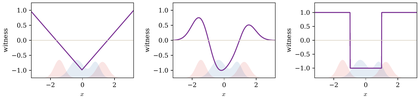

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dualnorms-ipm-witnesses.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dualnorms-ipm-witnesses.png")
display(Image(filename=str(_thumb)))
